# Reto 02 — Comparación de algoritmos para Multi-Armed Bandits

**Integrantes:** Sebastián Roldán  \n
**Correos:** sebastian.roldan93@eia.edu.co  \n
**Fecha:** 2026-08-18

## Objetivo

Describe el objetivo del experimento y la pregunta que deseas responder.

## 1. Preparación del entorno

In [492]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from challenges.challenge_02_bandit_algorithms.starter_code import (
    GaussianBandit,
    cumulative_average,
    cumulative_regret,
    optimal_action_rate,
)

SEED = 2026
HORIZON = 1_000
N_RUNS = 100
MEANS = np.array([1.0, 2.0, 1.5])
STDS = np.array([0.5, 0.5, 1.5])
ARM_NAMES = np.array(["A1", "A2", "A3"])

## 2. Verificación del bandit

Crea el entorno, muestra sus propiedades y explica por qué A2 es el brazo óptimo.

In [493]:
bandit = GaussianBandit(MEANS, STDS, seed=SEED)
print(f"Número de brazos: {bandit.n_arms}")
print(f"Brazo óptimo: {ARM_NAMES[bandit.optimal_arm]}")
print(f"Media óptima: {bandit.optimal_mean}")

Número de brazos: 3
Brazo óptimo: A2
Media óptima: 2.0


## 3. Funciones auxiliares

Implementa actualización incremental y selección aleatoria entre empates.

In [494]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    max = np.max(values)
    indices_max = np.flatnonzero(values == max)
    return rng.choice(indices_max)


def incremental_update(estimate: float, reward: float, count: int) -> float:
    estimate_i = estimate + 1/count * (reward - estimate)
    return estimate_i

## 4. ε-greedy

In [495]:
def run_epsilon_greedy(
    *,
    epsilon: float,
    initial_value: float,
    horizon: int,
    seed: int,
) -> pd.DataFrame:

    # Validar parámetros
    if not 0 <= epsilon <= 1:
        raise ValueError("epsilon debe estar entre 0 y 1.")

    if horizon <= 0:
        raise ValueError("horizon debe ser mayor que 0.")

    # Generador aleatorio
    rng = np.random.default_rng(seed)

    # Inicializar estimaciones y conteos
    estimates = np.full(bandit.n_arms, initial_value, dtype=float)
    counts = np.zeros(bandit.n_arms, dtype=int)

    # Guardar resultados
    results = []

    for step in range(1, horizon + 1):

        # Exploración vs explotación
        if rng.random() < epsilon:
            action = rng.integers(bandit.n_arms)
        else:
            action = random_argmax(estimates, rng)

        # Obtener recompensa del brazo seleccionado
        reward = bandit.pull(action)

        # Actualizar contador
        counts[action] += 1

        # Actualizar estimación de la media
        estimates[action] = incremental_update(
            estimates[action],
            reward,
            counts[action]
        )

        # Guardar resultados
        results.append({
            "step": step,
            "action": action,
            "reward": reward,
            "estimate": estimates[action],
            "count": counts[action],
        })

    return pd.DataFrame(results)

In [496]:
results = run_epsilon_greedy(
    epsilon=0.1,
    initial_value=0.0,
    horizon=1000,
    seed=2026,
)

print(results["action"].value_counts().sort_index())

action
0     52
1    914
2     34
Name: count, dtype: int64


## 5. ε-greedy con inicio optimista

Reutiliza la implementación anterior con ε = 0 y Q0 = 5. Explica el mecanismo de exploración.

In [497]:
df_optimista = run_epsilon_greedy(epsilon=0,
    initial_value=5,
    horizon=1000,
    seed=2026)

print(df_optimista.tail())
print("\nConteo de acciones:")
print(df_optimista["action"].value_counts().sort_index())

     step  action    reward  estimate  count
995   996       1  0.969883  1.953832    992
996   997       1  2.359586  1.954241    993
997   998       1  1.418047  1.953701    994
998   999       1  2.419009  1.954169    995
999  1000       1  2.493848  1.954711    996

Conteo de acciones:
action
0      1
1    996
2      3
Name: count, dtype: int64


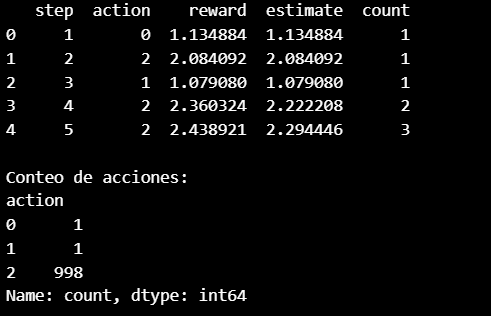

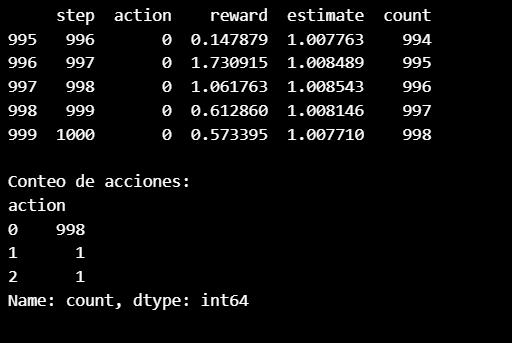

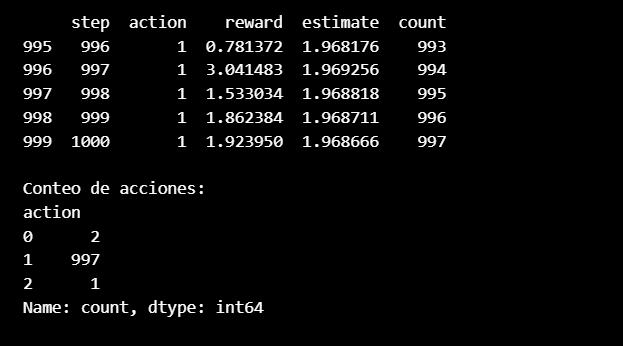

## 6. UCB

In [498]:
def run_ucb(*, c: float, horizon: int, seed: int) -> pd.DataFrame:
    if c < 0:
        raise ValueError("c debe ser mayor o igual a 0")

    if horizon <= 0:
        raise ValueError("horizon debe ser mayor que 0")

    # Aleatorio
    rng = np.random.default_rng(seed)

    n_arms = bandit.n_arms

    Q = np.zeros(n_arms, dtype=float)
    counts = np.zeros(n_arms, dtype=int)

    results = []

    for step in range(1, horizon + 1):

        # Primero probar cada brazo al menos una vez
        if step <= n_arms:
            action = step - 1

        else:
            # Fórmula UCB:
            #
            # Q(a) + c * sqrt(log(t) / N(a))
            #
            confidence = c * np.sqrt(np.log(step) / counts)

            ucb_values = Q + confidence

            action = random_argmax(ucb_values, rng)

        # Obtener recompensa
        reward = bandit.pull(action)

        # Actualizar conteo
        counts[action] += 1

        # Actualizar media estimada
        Q[action] = incremental_update(Q[action],
            reward,
            counts[action])

        results.append({
            "step": step,
            "action": action,
            "reward": reward,
            "estimate": Q[action],
            "optimal_action": bandit.optimal_arm,
            "regret": bandit.optimal_mean - reward})

    df = pd.DataFrame(results)

    df["cumulative_reward"] = df["reward"].cumsum()
    df["cumulative_regret"] = df["regret"].cumsum()
    df["optimal"] = df["action"] == df["optimal_action"]

    return df

In [499]:
df_ucb = run_ucb(
    c=2,
    horizon=1000,
    seed=2026
)

print("\nUCB")
print(df_ucb.head())
print("\nConteo de acciones:")
print(df_ucb["action"].value_counts().sort_index())


UCB
   step  action    reward  estimate  optimal_action    regret  \
0     1       0  0.794981  0.794981               1  1.205019   
1     2       1  1.782019  1.782019               1  0.217981   
2     3       2  1.467421  1.467421               1  0.532579   
3     4       1  2.059162  1.920590               1 -0.059162   
4     5       2  1.195472  1.331446               1  0.804528   

   cumulative_reward  cumulative_regret  optimal  
0           0.794981           1.205019    False  
1           2.577000           1.423000     True  
2           4.044421           1.955579    False  
3           6.103583           1.896417     True  
4           7.299055           2.700945    False  

Conteo de acciones:
action
0     22
1    923
2     55
Name: count, dtype: int64


## 7. Softmax

In [500]:
def run_softmax(
    *, temperature: float, horizon: int, seed: int
) -> pd.DataFrame:
    if temperature <= 0:
        raise ValueError("temperature debe ser mayor que 0")

    if horizon <= 0:
        raise ValueError("horizon debe ser mayor que 0")

    # Aleatorio
    rng = np.random.default_rng(seed)

    n_arms = bandit.n_arms

    Q = np.zeros(n_arms, dtype=float)
    counts = np.zeros(n_arms, dtype=int)

    results = []

    for step in range(1, horizon + 1):
        # Restar el máximo evita problemas numéricos
        # cuando los valores de Q son grandes.
        logits = (Q - np.max(Q)) / temperature

        exp_values = np.exp(logits)

        probabilities = exp_values / np.sum(exp_values)

        # Elegir un brazo de acuerdo con las probabilidades
        action = rng.choice(n_arms,
            p=probabilities)

        # Obtener recompensa
        reward = bandit.pull(action)

        # Actualizar conteo
        counts[action] += 1

        # Actualizar estimación
        Q[action] = incremental_update(Q[action],
            reward,
            counts[action])

        results.append({
            "step": step,
            "action": action,
            "reward": reward,
            "estimate": Q[action],
            "optimal_action": bandit.optimal_arm,
            "regret": bandit.optimal_mean - reward})

    df = pd.DataFrame(results)

    df["cumulative_reward"] = df["reward"].cumsum()
    df["cumulative_regret"] = df["regret"].cumsum()
    df["optimal"] = df["action"] == df["optimal_action"]

    return df

In [501]:
df_softmax = run_softmax(temperature=0.5,
    horizon=1000,
    seed=2026)

print("\nSoftmax")
print(df_softmax.head())
print("\nConteo de acciones:")
print(df_softmax["action"].value_counts().sort_index())


Softmax
   step  action    reward  estimate  optimal_action    regret  \
0     1       0  0.773998  0.773998               1  1.226002   
1     2       0  0.823452  0.798725               1  1.176548   
2     3       0  0.528832  0.708761               1  1.471168   
3     4       0  1.005511  0.782948               1  0.994489   
4     5       0  1.595223  0.945403               1  0.404777   

   cumulative_reward  cumulative_regret  optimal  
0           0.773998           1.226002    False  
1           1.597450           2.402550    False  
2           2.126282           3.873718    False  
3           3.131793           4.868207    False  
4           4.727016           5.272984    False  

Conteo de acciones:
action
0    100
1    653
2    247
Name: count, dtype: int64


## 8. Pruebas pequeñas

Verifica longitud, acciones válidas, conteos y reproducibilidad antes del experimento completo.

In [502]:
# ε-greedy
epsilon_1 = run_epsilon_greedy(
    epsilon=0.1,
    initial_value=0,
    horizon=20,
    seed=SEED
)

epsilon_2 = run_epsilon_greedy(
    epsilon=0,
    initial_value=5,
    horizon=20,
    seed=SEED
)

assert len(epsilon_1) == 20
assert epsilon_1["action"].between(0, len(MEANS) - 1).all()
assert epsilon_1["action"].value_counts().sum() == 20

assert len(epsilon_2) == 20
assert epsilon_2["action"].between(0, len(MEANS) - 1).all()
assert epsilon_2["action"].value_counts().sum() == 20

In [503]:
# UCB
ucb = run_ucb(c=2,
    horizon=20,
    seed=SEED)

assert len(ucb) == 20
assert ucb["action"].between(0, len(MEANS) - 1).all()
assert ucb["action"].value_counts().sum() == 20

In [504]:
softmax_1 = run_softmax(temperature=0.1,
    horizon=20,
    seed=SEED)

softmax_2 = run_softmax(temperature=10,
    horizon=20,
    seed=SEED)

assert len(softmax_1) == 20
assert softmax_1["action"].between(0, len(MEANS) - 1).all()
assert softmax_1["action"].value_counts().sum() == 20

assert len(softmax_2) == 20
assert softmax_2["action"].between(0, len(MEANS) - 1).all()
assert softmax_2["action"].value_counts().sum() == 20

## 9. Comparación principal

Ejecuta 100 corridas de 1.000 pasos por algoritmo. Agrega las curvas y reporta su variabilidad.

In [505]:
HORIZON = 1000
N_RUNS = 100
todas = []

# ε-greedy
for run in range(N_RUNS):
    df = run_epsilon_greedy(epsilon=0.1, initial_value=0, horizon=HORIZON, seed=SEED+run)
    df["algoritmo"] = "ε-greedy"
    df["corrida"] = run
    todas.append(df)


# ε-greedy optimista
for run in range(N_RUNS):
    df = run_epsilon_greedy(epsilon=0, initial_value=5, horizon=HORIZON, seed=SEED+run)
    df["algoritmo"] = "Inicio optimista"
    df["corrida"] = run
    todas.append(df)

# UCB
for run in range(N_RUNS):
    df = run_ucb(c=2, horizon=HORIZON, seed=SEED+run)
    df["algoritmo"] = "UCB"
    df["corrida"] = run
    todas.append(df)

# Softmax
for run in range(N_RUNS):
    df = run_softmax(temperature=0.5, horizon=HORIZON, seed=SEED+run)
    df["algoritmo"] = "Softmax"
    df["corrida"] = run
    todas.append(df)

results = pd.concat(todas, ignore_index=True)

print(results.head())

   step  action    reward  estimate  count algoritmo  corrida  optimal_action  \
0     1       0  1.477483  1.477483    1.0  ε-greedy        0             NaN   
1     2       0  1.853179  1.665331    2.0  ε-greedy        0             NaN   
2     3       0  0.906042  1.412235    3.0  ε-greedy        0             NaN   
3     4       0  0.522526  1.189808    4.0  ε-greedy        0             NaN   
4     5       0  1.074683  1.166783    5.0  ε-greedy        0             NaN   

   regret  cumulative_reward  cumulative_regret optimal  
0     NaN                NaN                NaN     NaN  
1     NaN                NaN                NaN     NaN  
2     NaN                NaN                NaN     NaN  
3     NaN                NaN                NaN     NaN  
4     NaN                NaN                NaN     NaN  


In [506]:
# Brazo óptimo: A2 -> índice 1
results["optimal_action"] = np.argmax(MEANS)

# Regret de cada observación
results["regret"] = np.max(MEANS) - results["reward"]

# Indica si se escogió el brazo óptimo
results["optimal"] = (
    results["action"] == results["optimal_action"]
)

# Acumulados independientes para cada algoritmo y corrida
results["cumulative_reward"] = (
    results
    .groupby(["algoritmo", "corrida"])["reward"]
    .cumsum()
)

results["cumulative_regret"] = (
    results
    .groupby(["algoritmo", "corrida"])["regret"]
    .cumsum()
)

print(results.shape)
print(results.head())
print(results["algoritmo"].value_counts())

(400000, 12)
   step  action    reward  estimate  count algoritmo  corrida  optimal_action  \
0     1       0  1.477483  1.477483    1.0  ε-greedy        0               1   
1     2       0  1.853179  1.665331    2.0  ε-greedy        0               1   
2     3       0  0.906042  1.412235    3.0  ε-greedy        0               1   
3     4       0  0.522526  1.189808    4.0  ε-greedy        0               1   
4     5       0  1.074683  1.166783    5.0  ε-greedy        0               1   

     regret  cumulative_reward  cumulative_regret  optimal  
0  0.522517           1.477483           0.522517    False  
1  0.146821           3.330662           0.669338    False  
2  1.093958           4.236704           1.763296    False  
3  1.477474           4.759231           3.240769    False  
4  0.925317           5.833914           4.166086    False  
algoritmo
ε-greedy            100000
Inicio optimista    100000
UCB                 100000
Softmax             100000
Name: count, dty

## 10. Tabla resumen y visualizaciones

Incluye recompensa, acción óptima, regret y distribución final de acciones.

In [507]:
tabla_resumen = (
    results
    .groupby(["algoritmo", "corrida"]).agg(recompensa_total=("reward", "sum"),
        recompensa_promedio=("reward", "mean"),
        regret_total=("regret", "sum"),
        porcentaje_optimo=("optimal", "mean")).groupby("algoritmo").agg(recompensa_total_promedio=("recompensa_total", "mean"),
        recompensa_total_std=("recompensa_total", "std"),
        recompensa_promedio=("recompensa_promedio", "mean"),
        regret_promedio=("regret_total", "mean"),
        regret_std=("regret_total", "std"),
        porcentaje_optimo=("porcentaje_optimo", "mean"),
    ).reset_index())

tabla_resumen["porcentaje_optimo"] = tabla_resumen["porcentaje_optimo"] * 100

tabla_resumen = tabla_resumen.sort_values("recompensa_total_promedio", ascending=False)

tabla_resumen

,algoritmo,recompensa_total_promedio,recompensa_total_std,recompensa_promedio,regret_promedio,regret_std,porcentaje_optimo
0,Inicio optimista,1972.552099,136.867470,1.972552,27.447901,136.867470,95.508
2,UCB,1953.022515,19.189031,1.953023,46.977485,19.189031,92.227
3,ε-greedy,1934.565876,26.162591,1.934566,65.434124,26.162591,90.777
1,Softmax,1795.065897,39.976068,1.795066,204.934103,39.976068,68.649


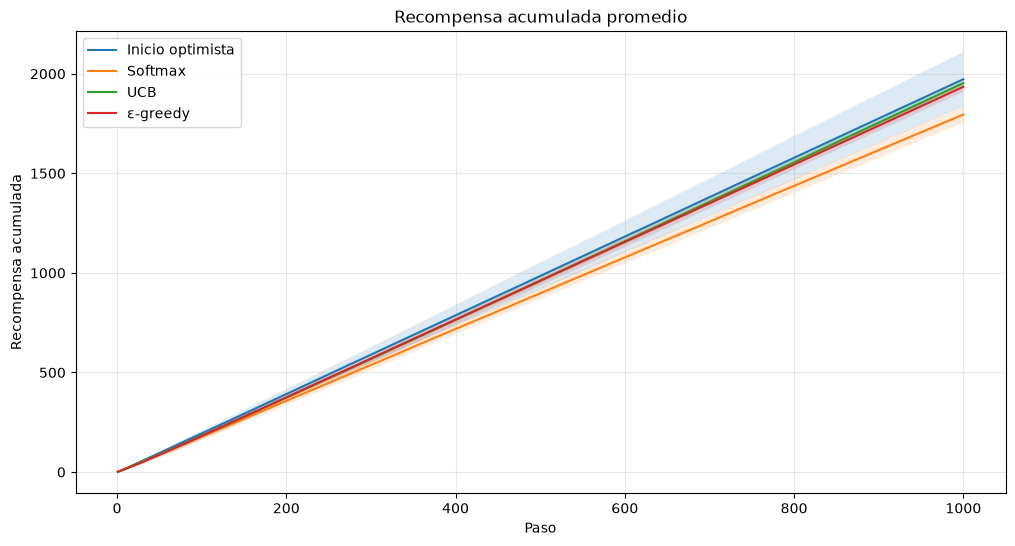

In [ ]:
curvas = (results.groupby(["algoritmo", "step"]).agg(media=("cumulative_reward", "mean"), std=("cumulative_reward", "std")).reset_index())

plt.figure(figsize=(12, 6))

for algoritmo in curvas["algoritmo"].unique():
    datos = curvas[curvas["algoritmo"] == algoritmo]
    plt.plot(datos["step"], datos["media"], label=algoritmo)
    plt.fill_between(datos["step"],datos["media"] - datos["std"], datos["media"] + datos["std"], alpha=0.15)

plt.xlabel("Paso")
plt.ylabel("Recompensa acumulada")
plt.title("Recompensa acumulada promedio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

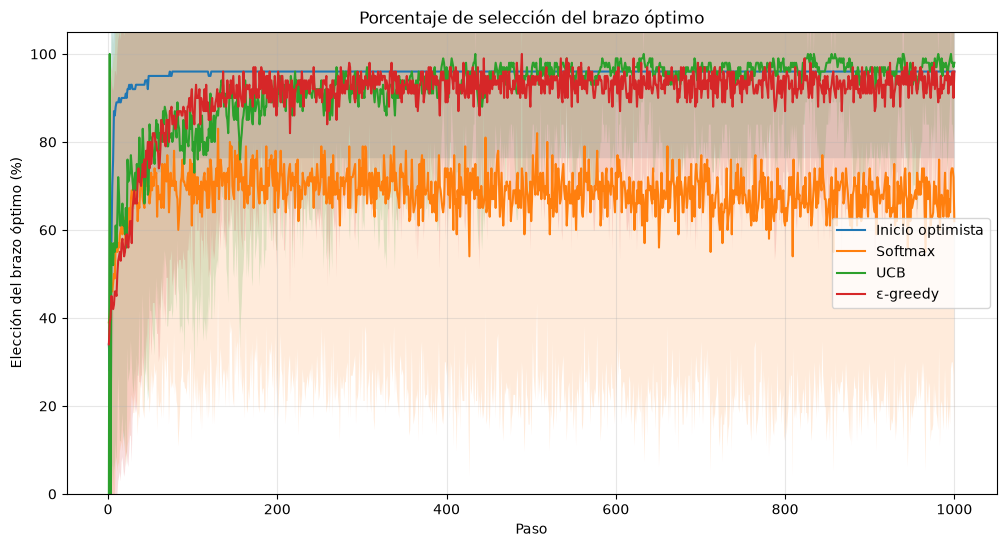

In [ ]:
curvas_optimal = (results.groupby(["algoritmo", "step"]).agg(media=("optimal", "mean"), std=("optimal", "std")).reset_index())

curvas_optimal["media"] *= 100
curvas_optimal["std"] *= 100

plt.figure(figsize=(12, 6))

for algoritmo in curvas_optimal["algoritmo"].unique():
    datos = curvas_optimal[curvas_optimal["algoritmo"] == algoritmo]
    plt.plot(datos["step"],datos["media"],label=algoritmo)
    plt.fill_between( datos["step"], datos["media"] - datos["std"], datos["media"] + datos["std"],  alpha=0.15)

plt.xlabel("Paso")
plt.ylabel("Elección del brazo óptimo (%)")
plt.title("Porcentaje de selección del brazo óptimo")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

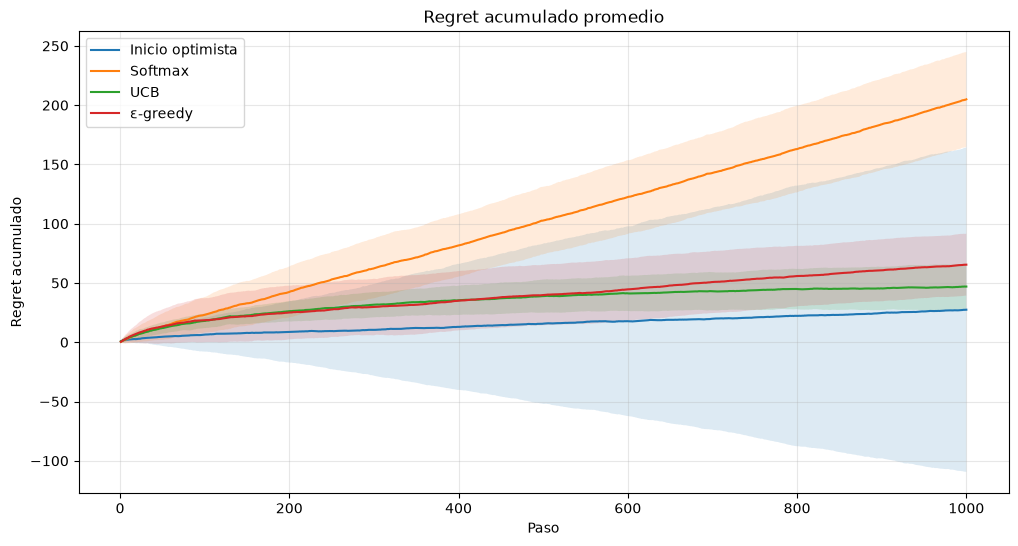

In [ ]:
curvas_regret = (results.groupby(["algoritmo", "step"]).agg(media=("cumulative_regret", "mean"), std=("cumulative_regret", "std")).reset_index())
plt.figure(figsize=(12, 6))

for algoritmo in curvas_regret["algoritmo"].unique():
    datos = curvas_regret[curvas_regret["algoritmo"] == algoritmo]
    plt.plot(datos["step"], datos["media"], label=algoritmo)
    plt.fill_between(datos["step"], datos["media"] - datos["std"], datos["media"] + datos["std"], alpha=0.15)

plt.xlabel("Paso")
plt.ylabel("Regret acumulado")
plt.title("Regret acumulado promedio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

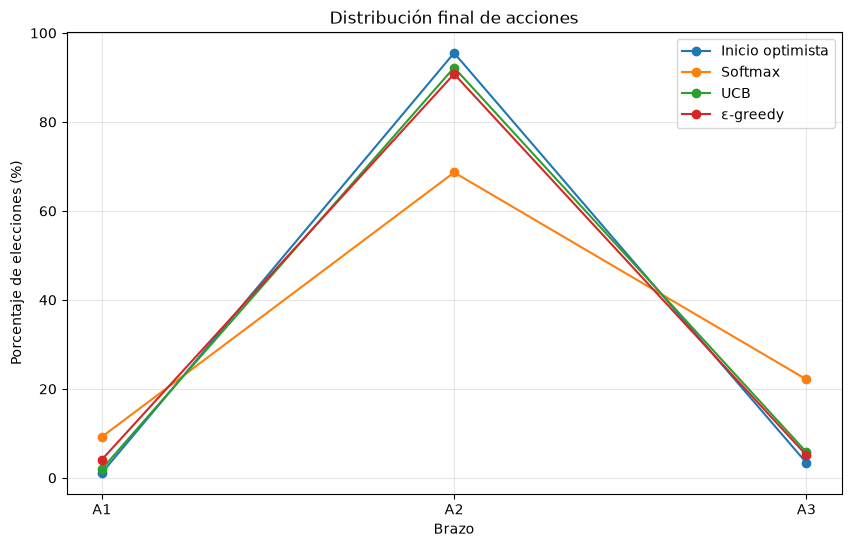

In [ ]:
distribucion = (results.groupby(["algoritmo", "action"]).size().reset_index(name="cantidad"))

# Convertir a porcentaje dentro de cada algoritmo
distribucion["porcentaje"] = (distribucion.groupby("algoritmo")["cantidad"].transform(lambda x: x / x.sum() * 100))

# Cambiar índices por nombres
distribucion["brazo"] = distribucion["action"].map({0: "A1", 1: "A2", 2: "A3"})

plt.figure(figsize=(10, 6))

for algoritmo in distribucion["algoritmo"].unique():
    datos = distribucion[distribucion["algoritmo"] == algoritmo]
    plt.plot(datos["brazo"],datos["porcentaje"],marker="o",label=algoritmo)

plt.xlabel("Brazo")
plt.ylabel("Porcentaje de elecciones (%)")
plt.title("Distribución final de acciones")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

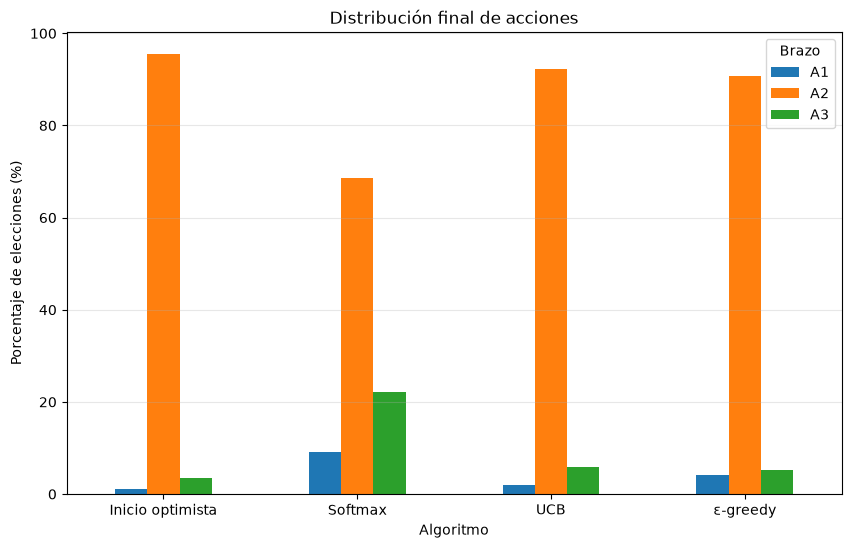

In [ ]:
plt.figure(figsize=(10, 6))

distribucion_pivot = distribucion.pivot(index="algoritmo",columns="brazo", values="porcentaje")

distribucion_pivot.plot( kind="bar", figsize=(10, 6))

plt.xlabel("Algoritmo")
plt.ylabel("Porcentaje de elecciones (%)")
plt.title("Distribución final de acciones")
plt.xticks(rotation=0)
plt.legend(title="Brazo")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 11. Sensibilidad de hiperparámetros

Compara los valores de ε, Q0, c y τ indicados en el enunciado.

In [513]:
HORIZON = 1000
N_RUNS = 100

resultados_sensibilidad = []

valores_epsilon = [0.01, 0.1, 0.3]

for epsilon in valores_epsilon:

    for run in range(N_RUNS):

        df = run_epsilon_greedy(
            epsilon=epsilon,
            initial_value=0,
            horizon=HORIZON,
            seed=SEED + run
        )

        df["algoritmo"] = "ε-greedy"
        df["hiperparametro"] = "epsilon"
        df["valor"] = epsilon
        df["corrida"] = run

        resultados_sensibilidad.append(df)


valores_Q0 = [2, 5, 10]

for Q0 in valores_Q0:

    for run in range(N_RUNS):

        df = run_epsilon_greedy(
            epsilon=0,
            initial_value=Q0,
            horizon=HORIZON,
            seed=SEED + run
        )

        df["algoritmo"] = "Inicio optimista"
        df["hiperparametro"] = "Q0"
        df["valor"] = Q0
        df["corrida"] = run

        resultados_sensibilidad.append(df)


valores_c = [0.5, 1, 2]

for c in valores_c:

    for run in range(N_RUNS):

        df = run_ucb(
            c=c,
            horizon=HORIZON,
            seed=SEED + run
        )

        df["algoritmo"] = "UCB"
        df["hiperparametro"] = "c"
        df["valor"] = c
        df["corrida"] = run

        resultados_sensibilidad.append(df)



valores_tau = [0.05, 0.2, 1.0]

for tau in valores_tau:

    for run in range(N_RUNS):

        df = run_softmax(
            temperature=tau,
            horizon=HORIZON,
            seed=SEED + run
        )

        df["algoritmo"] = "Softmax"
        df["hiperparametro"] = "tau"
        df["valor"] = tau
        df["corrida"] = run

        resultados_sensibilidad.append(df)


sensibilidad = pd.concat(
    resultados_sensibilidad,
    ignore_index=True
)

print(sensibilidad.groupby(["algoritmo", "hiperparametro", "valor"])["corrida"].nunique())

algoritmo         hiperparametro  valor
Inicio optimista  Q0              2.00     100
                                  5.00     100
                                  10.00    100
Softmax           tau             0.05     100
                                  0.20     100
                                  1.00     100
UCB               c               0.50     100
                                  1.00     100
                                  2.00     100
ε-greedy          epsilon         0.01     100
                                  0.10     100
                                  0.30     100
Name: corrida, dtype: int64


In [514]:
metricas_corrida = (sensibilidad.groupby(["algoritmo", "hiperparametro", "valor", "corrida"]).agg(recompensa_total=("reward", "sum"),
        regret_final=("cumulative_regret", "last"),
        recompensa_final=("cumulative_reward", "last"),
        tasa_optima=("optimal", "mean")).reset_index())

In [515]:
metricas_corrida[metricas_corrida.algoritmo == "UCB"].groupby(['valor']).agg(media_recompensa=('recompensa_final','mean'),
        media_regret=('regret_final','mean'), media_tasa=('tasa_optima','mean'))

,media_recompensa,media_regret,media_tasa
valor,,,
0.5,1993.593994,6.406006,0.99162
1.0,1986.759076,13.240924,0.97697
2.0,1948.360558,51.639442,0.91477


## 12. Interpretación

Responde las nueve preguntas del enunciado con evidencia de tus resultados.

Qué algoritmo obtuvo mayor recompensa acumulada?

El de inicio optimista con muy poca diferencia al UCB

Cuál identificó más rápido el brazo óptimo?

El mismo del inicio optimista, por eso probablemente sea la mayor recompensa

Cuál obtuvo menor regret final?

También el optimista

Qué comportamiento produjo el inicio optimista?

Una gran explotación al brazo encontrado para tener la mayor recompensa, además de lo obligado que debe explorar al menos 1 vez cada brazo porque con el q0 = 5, mayor a cualquiera de las medias, lo más probable es que cualquiera de las recompensas sea más baja y quede por debajo de los otros 2 brazos

Cómo cambia el UCB al modificar c?

Con la confianza más baja tiende a explotar más, por lo que con el valor mínimo que usamos de 0.5 se ve mayor recompensa promedio, menor regret promedio y mayor tasa de brazo óptimo promedio

Cuál estrategia fue más sensible a la varianza de A3?

Softmax, esta fue la que más utilizó el brazo 3, esto porque las probabilidades de selección dependen de la recompensas estimadas y un valor alto de A3 puede darle mayor probabilidad de selección 

Existe un algoritmo ganador para todas las métricas y horizontes?

No. El mejor algoritmo va a cambiar según el problema, además que el horizonte va a cambiar también la exactitud en la aproximación, por lo que un horizonte bajo puede crear sesgos.

Qué método recomendarías y bajo qué condiciones?
Realmente recomendaría probar todos con diferentes parámetros para encontrar cuál es el mejor. Probablemente conociendo la escala de la recompensa podrían funcionar bien UCB y optimista.


## 13. Uso de inteligencia artificial

Documenta herramientas, preguntas, sugerencias, ajustes manuales y validación.

"""
Tengo este notebook con el que resolví un reto de k-armed bandits, basado en esto y una iniciación entregada por mi profesor (pego iniciación), entrégame las funciones necesarias para correr los algoritmos ε-greedy, UCB y softmax
"""

Acá quité todos los generadores de un nuevo bandit o nuevo entorno que me ofrecía la IA

"""
Tengo

HORIZON = 1000
N_RUNS = 100
todas = []

# ε-greedy
for run in range(N_RUNS):
    df = run_epsilon_greedy(epsilon=0.1, initial_value=0, horizon=HORIZON, seed=SEED + run)
    df["algoritmo"] = "ε-greedy"
    df["corrida"] = run
    todas.append(df)


# ε-greedy optimista
for run in range(N_RUNS):
    df = run_epsilon_greedy(epsilon=0, initial_value=5, horizon=HORIZON, seed=SEED + run)
    df["algoritmo"] = "Inicio optimista"
    df["corrida"] = run
    todas.append(df)

# UCB
for run in range(N_RUNS):
    df = run_ucb(c=2, horizon=HORIZON, seed=SEED + run)
    df["algoritmo"] = "UCB"
    df["corrida"] = run
    todas.append(df)

# Softmax
for run in range(N_RUNS):
    df = run_softmax(temperature=0.5, horizon=HORIZON, seed=SEED + run)
    df["algoritmo"] = "Softmax"
    df["corrida"] = run
    todas.append(df)

results = pd.concat(todas, ignore_index=True)

step  action    reward  estimate  count algoritmo  corrida  optimal_action  \
0     1       0  0.882573  0.882573    1.0  ε-greedy        0             NaN   
1     2       0  0.487721  0.685147    2.0  ε-greedy        0             NaN   
2     3       0  1.729327  1.033207    3.0  ε-greedy        0             NaN   
3     4       0  1.010329  1.027487    4.0  ε-greedy        0             NaN   
4     5       0  0.500077  0.922005    5.0  ε-greedy        0             NaN   

   regret  cumulative_reward  cumulative_regret optimal  
0     NaN                NaN                NaN     NaN  
1     NaN                NaN                NaN     NaN  
2     NaN                NaN                NaN     NaN  
3     NaN                NaN                NaN     NaN  
4     NaN                NaN                NaN     NaN

Pero estoy teniendo muchos NaNs, es normal?
"""

"""
Qué asersiones me recomiendas hacer acá?
"""

## 14. Conclusiones

Incluye entre cuatro y seis conclusiones sustentadas en el experimento.


No existe un algoritmo ganador universal. Inicio optimista y UCB (c=2) lideraron en recompensa y regret con una diferencia mínima entre ellos (~0.2%), mientras que UCB tuvo una tasa de acierto ligeramente mayor. La elección del "mejor" algoritmo depende de la métrica priorizada y de qué tan bien calibrados estén sus hiperparámetros.

El inicio optimista y UCB deben su buen desempeño a mecanismos de exploración distintos pero eficientes en este problema. El inicio optimista explora "por decepción" (Q0=5 fuerza a probar cada brazo hasta que sus estimaciones bajan a niveles realistas), mientras que UCB explora según la incertidumbre acumulada, controlada por c: bajar c de 2 a 0.5 mejoró notablemente el regret (50.1 → 7.3) y la tasa de acierto (92.1% → 98.9%), mostrando que una confianza baja fue más eficiente dado que la incertidumbre real del problema era menor de lo asumido.

Softmax fue el más sensible al ruido, particularmente al del brazo A3 (std=1.5, la más alta de los tres). Con temperatura baja (τ=0.5), pequeñas diferencias en las medias estimadas se amplifican exponencialmente en las probabilidades de selección, lo que hizo que A3 fuera elegido ~29% del tiempo frente a solo 3-6% en los demás algoritmos, penalizando su desempeño global.

La ventaja de UCB e inicio optimista depende de conocer la escala del problema, algo que no siempre está disponible de antemano en un caso real; además, al revisar el código detectamos una limitación en el muestreo de la comparación principal (semilla no variada entre corridas para todos los algoritmos por igual), que reduce la confiabilidad de las cifras exactas de variabilidad aunque no invalida los patrones cualitativos observados.